# XGBoost

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.models.xgboost import *

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## I. Full data

In [2]:
inf_data = pd.read_csv('..//data//processed//combined_macro_data.csv').set_index(['Date'])
inf_data.index = pd.to_datetime(inf_data.index)
inf_rate = inf_data['InflationRate'].dropna()

In [3]:
target_col = 'InflationRate'
final_inf, forecast_feat = train_forecast_split(inf_rate, target_col) 
final_inf.tail()

,InflationRate,Month_Sin,Month_Cos,InflationRate_Lag1,InflationRate_Lag2,InflationRate_Lag13,InflationRate_Lag24,InflationRate_RollMean3,InflationRate_RollSTD3,InflationRate_RollMean6,InflationRate_RollSTD6,InflationRate_RollMean12,InflationRate_RollSTD12
Date,,,,,,,,,,,,,
2026-01-01,2.024922,0.500000,8.660254e-01,1.801096,1.496063,2.900886,2.800659,1.652413,0.152661,1.524755,0.308271,1.659842,0.482085
2026-02-01,2.419984,0.866025,5.000000e-01,2.024922,1.801096,2.884615,3.377265,1.774027,0.265467,1.704139,0.200157,1.588201,0.320240
2026-03-01,4.068858,1.000000,6.123234e-17,2.419984,2.024922,2.071713,3.715937,2.082001,0.313367,1.857338,0.325754,1.617223,0.378521
2026-04-01,7.227023,0.866025,-5.000000e-01,4.068858,2.419984,1.751592,3.804797,2.837921,1.084169,2.245167,0.949273,1.810329,0.804591
2026-05-01,6.761006,0.500000,-8.660254e-01,7.227023,4.068858,1.434263,3.887510,4.571955,2.442690,3.172991,2.182522,2.293059,1.745744


In [4]:
test_results = test_diag(final_inf, 'InflationRate', n_iter = 100)

Rows      : 821
CV RMSE   : 0.541
Test RMSE : 0.942
Test STD  : 1.581
R²        : 0.645
Best Params:
{'colsample_bytree': 0.9823598442410485, 'gamma': 3.970985823468025, 'learning_rate': 0.009663111819311426, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 2176, 'reg_alpha': 0.002654338379455361, 'reg_lambda': 91.56208974433525, 'subsample': 0.693012319380772}


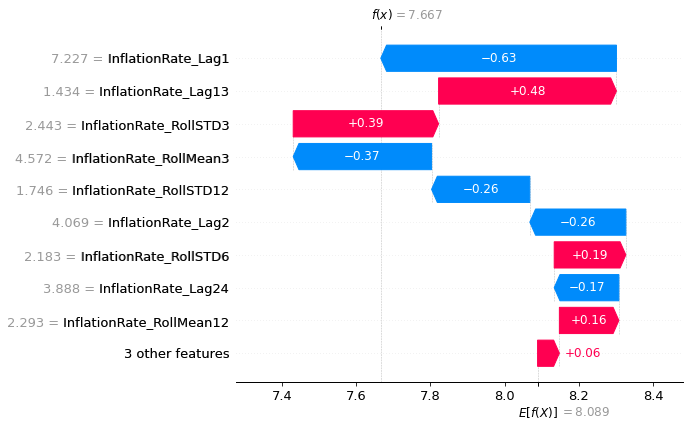

In [5]:
months_ahead = 6
nexog_forecast = months_ahead_forecast(inf_rate, target_col, months_ahead = months_ahead)

In [6]:
print(nexog_forecast)

            InflationRate
Date                     
2026-06-01       7.666690
2026-07-01       7.125916
2026-08-01       8.591007
2026-09-01       8.021852
2026-10-01       8.867754
2026-11-01       8.774572


## II. Reduced data

In [7]:
inf_full = inf_data.dropna()
inf_red, red_forecast_feat = train_forecast_split(inf_full[target_col], target_col) 
inf_red.tail()

,InflationRate,Month_Sin,Month_Cos,InflationRate_Lag1,InflationRate_Lag2,InflationRate_Lag13,InflationRate_Lag24,InflationRate_RollMean3,InflationRate_RollSTD3,InflationRate_RollMean6,InflationRate_RollSTD6,InflationRate_RollMean12,InflationRate_RollSTD12
Date,,,,,,,,,,,,,
2026-01-01,2.024922,0.500000,8.660254e-01,1.801096,1.496063,2.900886,2.800659,1.652413,0.152661,1.524755,0.308271,1.659842,0.482085
2026-02-01,2.419984,0.866025,5.000000e-01,2.024922,1.801096,2.884615,3.377265,1.774027,0.265467,1.704139,0.200157,1.588201,0.320240
2026-03-01,4.068858,1.000000,6.123234e-17,2.419984,2.024922,2.071713,3.715937,2.082001,0.313367,1.857338,0.325754,1.617223,0.378521
2026-04-01,7.227023,0.866025,-5.000000e-01,4.068858,2.419984,1.751592,3.804797,2.837921,1.084169,2.245167,0.949273,1.810329,0.804591
2026-05-01,6.761006,0.500000,-8.660254e-01,7.227023,4.068858,1.434263,3.887510,4.571955,2.442690,3.172991,2.182522,2.293059,1.745744


In [8]:
test_red_results = test_diag(inf_red, 'InflationRate', n_iter = 100)

Rows      : 257
CV RMSE   : 0.837
Test RMSE : 0.912
Test STD  : 1.581
R²        : 0.667
Best Params:
{'colsample_bytree': 0.9604082439414403, 'gamma': 0.9009989024436044, 'learning_rate': 0.02228131332262713, 'max_depth': 8, 'min_child_weight': 9, 'n_estimators': 1181, 'reg_alpha': 0.15428032656618226, 'reg_lambda': 1.1058953027263159, 'subsample': 0.7742083053299873}


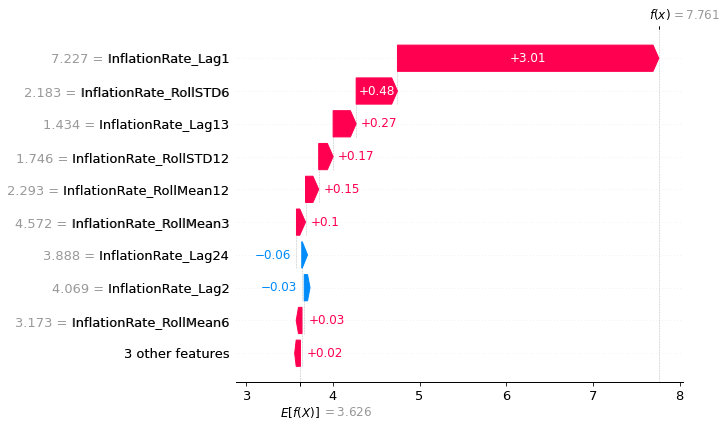

In [9]:
nexog_red_forecast = months_ahead_forecast(inf_full[target_col], target_col, months_ahead = months_ahead)

In [10]:
print(nexog_red_forecast)

            InflationRate
Date                     
2026-06-01       7.760535
2026-07-01       7.631982
2026-08-01       8.992358
2026-09-01       8.615250
2026-10-01       8.730096
2026-11-01       8.269925


## III. Reduced data with exogenous variables

In [11]:
inf_exog_full, forecast_feat = train_forecast_split(inf_full, target_col) 
inf_exog_full.tail()

,InflationRate,USD_PHP,UnemploymentRate,DubaiCrude,Month_Sin,Month_Cos,InflationRate_Lag1,InflationRate_Lag2,InflationRate_Lag13,InflationRate_Lag24,...,DubaiCrude_Lag1,DubaiCrude_Lag2,DubaiCrude_Lag13,DubaiCrude_Lag24,DubaiCrude_RollMean3,DubaiCrude_RollSTD3,DubaiCrude_RollMean6,DubaiCrude_RollSTD6,DubaiCrude_RollMean12,DubaiCrude_RollSTD12
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-01,2.024922,59.162190,5.8,62.728182,0.500000,8.660254e-01,1.801096,1.496063,2.900886,2.800659,...,61.830000,64.355500,74.002727,79.582174,63.594732,1.533132,66.855738,3.739892,69.391504,5.509725
2026-02-01,2.419984,58.280263,5.1,68.508500,0.866025,5.000000e-01,2.024922,1.801096,2.884615,3.377265,...,62.728182,61.830000,80.804348,82.809048,62.971227,1.280172,65.469927,3.403361,67.885156,4.480723
2026-03-01,4.068858,59.406905,5.0,126.706364,1.000000,6.123234e-17,2.419984,2.024922,2.071713,3.715937,...,68.508500,62.728182,76.321500,86.633810,64.355561,3.624481,65.323328,3.214538,67.234073,3.630370
2026-04-01,7.227023,60.291316,4.7,105.299091,0.866025,-5.000000e-01,4.068858,2.419984,1.751592,3.804797,...,126.706364,68.508500,72.978095,90.869545,85.981015,35.387406,74.787874,25.538037,71.711429,17.602620
2026-05-01,6.761006,61.441000,4.8,102.282308,0.500000,-8.660254e-01,7.227023,4.068858,1.434263,3.887510,...,105.299091,126.706364,68.489545,84.666087,100.171318,29.435835,81.571273,27.611536,74.778891,20.030007


In [12]:
test_exog_results = test_diag(inf_full, 'InflationRate', n_iter = 100)

Rows      : 257
CV RMSE   : 1.924
Test RMSE : 2.915
Test STD  : 1.581
R²        : -2.401
Best Params:
{'colsample_bytree': 0.5260203103049141, 'gamma': 3.2434365963372107, 'learning_rate': 0.04768857216302327, 'max_depth': 2, 'min_child_weight': 4, 'n_estimators': 346, 'reg_alpha': 8.528731285664739, 'reg_lambda': 0.13503306019388092, 'subsample': 0.5954323221327099}


c:\Users\PC\Desktop\Acads Stuff\Inflation Forecasting\src\models\xgboost.py:191: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[forecast_feat_exog.index[0], col] = exog_forecast


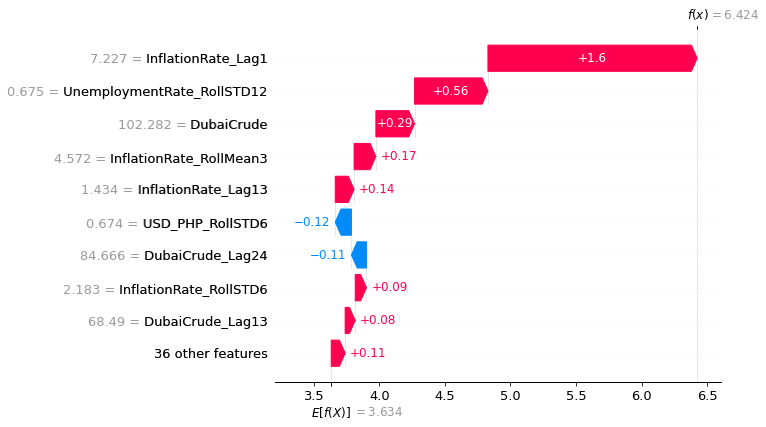

In [13]:
exog_forecast = months_ahead_forecast(inf_full, target_col, months_ahead = months_ahead)

In [14]:
print(exog_forecast)

            InflationRate    USD_PHP  UnemploymentRate  DubaiCrude
Date                                                              
2026-06-01       6.424090  59.548710          5.140977   94.246414
2026-07-01       6.894938  58.674183          5.076282   90.799149
2026-08-01       6.155706  58.777184          4.713942   85.652977
2026-09-01       6.280259  58.526009          4.735344   84.045143
2026-10-01       5.945511  58.589569          4.937060   80.858452
2026-11-01       5.776960  57.322430          4.694580   80.402954


## IV. All forecasts

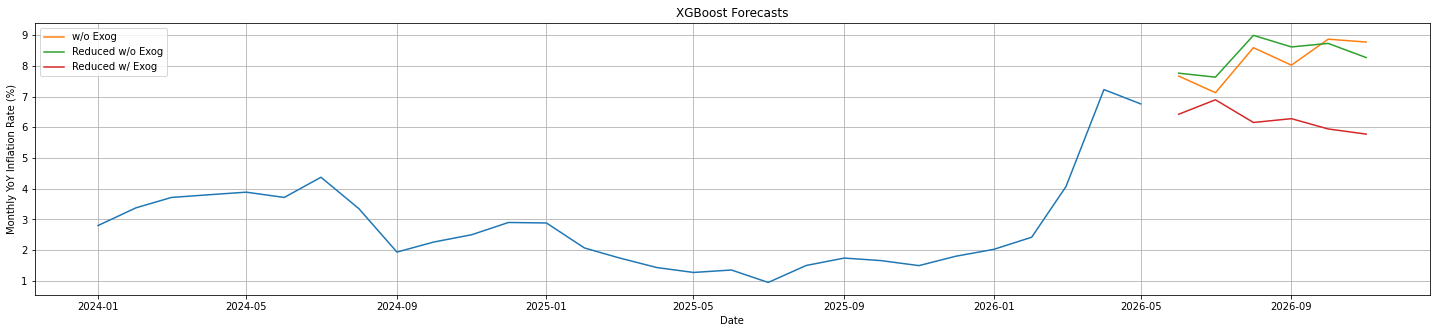

In [15]:
plt.figure(figsize = (25, 5))
plt.plot(inf_rate['2024':])
plt.title('XGBoost Forecasts')
plt.plot(nexog_forecast[target_col], label = 'w/o Exog')
plt.plot(nexog_red_forecast[target_col], label = 'Reduced w/o Exog')
plt.plot(exog_forecast[target_col], label = 'Reduced w/ Exog')
plt.xlabel('Date')
plt.ylabel('Monthly YoY Inflation Rate (%)')
plt.legend()
plt.grid(True)
plt.savefig('..//outputs//xgboost_forecast.jpg', dpi = 300, bbox_inches = 'tight')
plt.savefig('..//outputs//xgboost_forecast.png', dpi = 300, bbox_inches = 'tight')
plt.show()